# 4. Valutazione e Impatto Economico: Quanto Guadagneremo?
---
**Autore**: KickProphet Team

## 1. Introduzione
Un modello accurato al 90% può far perdere soldi se non è **ben calibrato**. 
In questo notebook finale, non ci limitiamo a contare gli errori. Traduciamo le performance del modello in **dollari**.

### **Obiettivi:**
1.  **Metriche Avanzate**: Brier Score, F1, Specificity.
2.  **Calibrazione**: Se il modello dice "80% di successo", il progetto ha davvero l'80% di probabilità di riuscita?
3.  **Ottimizzazione della Soglia**: Scegliere il cutoff di probabilità che massimizza il **Profitto**, non solo l'accuratezza.
4.  **ROI Analysis**: Stimare il ritorno sull'investimento.

In [8]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
)
from app.src import config

# --- 🎨 Stile Visuale ---
plt.style.use('seaborn-v0_8-paper')
sns.set_context("talk", font_scale=1.1)
KP_COLORS = ["#3498db", "#9b59b6", "#e74c3c", "#2ecc71", "#f1c40f"]
sns.set_palette(sns.color_palette(KP_COLORS))

def save_fig(name):
    path = os.path.join(config.RESULTS_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"💾 Figura salvata: {name}")

print("✅ Ambiente Configurato")

✅ Ambiente Configurato


## 2. Caricamento Modello e Dati di Test
Usiamo il Test Set "vergine" (mai visto in training o validation) per una valutazione onesta.

In [9]:
# Caricamento Dati
test_df = pd.read_csv(config.TEST_DATA_PATH)
y_test = test_df[config.TARGET_COL]
X_test = test_df.drop(columns=[config.TARGET_COL])

# Caricamento Modello (LGBM, XGBoost o Ensemble)
model = joblib.load(config.MODEL_PATH)

# Predizioni
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob > 0.5).astype(int)  # Soglia standard 0.5

print(f"📂 Test Set: {X_test.shape[0]} progetti")
print(f"🤖 Modello Caricato: {type(model).__name__}")

📂 Test Set: 37623 progetti
🤖 Modello Caricato: CalibratedClassifierCV


## 3. Metriche di Classificazione (Deep Dive)
Oltre all'Accuracy, ci interessano:
-   **Recall (Sensitivity)**: Quanti progetti di successo abbiamo "catturato"?
-   **Precision**: Di quelli che abbiamo detto "successo", quanti lo erano davvero?
-   **Brier Score**: L'errore quadratico medio delle probabilità. Più basso è, meglio è (0 = perfetto, 0.25 = casuale binario).

,Valore
Accuracy,0.817293
Precision,0.834109
Recall,0.881397
F1 Score,0.857101
Specificity,0.711957
Brier Score,0.125571


💾 Figura salvata: confusion_matrix_final.png


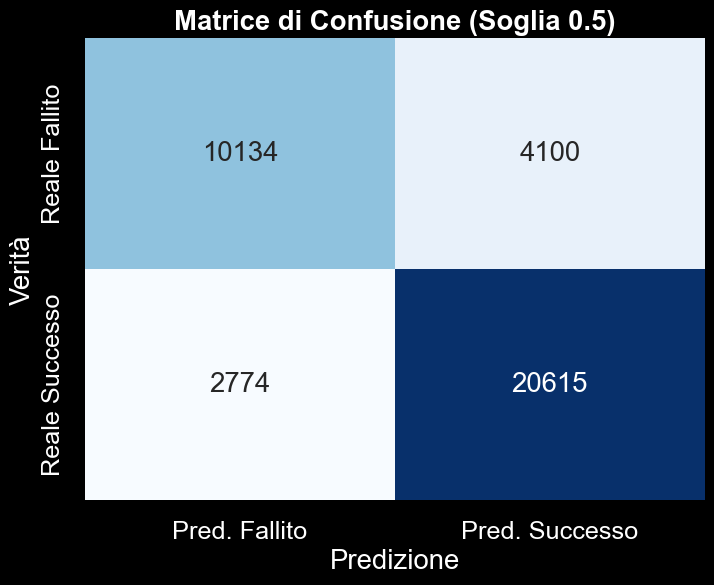

In [10]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default),
    'Recall': recall_score(y_test, y_pred_default),
    'F1 Score': f1_score(y_test, y_pred_default),
    'Specificity': tn / (tn + fp),
    'Brier Score': brier_score_loss(y_test, y_prob)
}

metrics_df = pd.DataFrame(metrics, index=['Valore']).T
display(metrics_df.style.background_gradient(cmap='Blues'))

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred. Fallito', 'Pred. Successo'],
            yticklabels=['Reale Fallito', 'Reale Successo'])
plt.title('Matrice di Confusione (Soglia 0.5)', fontweight='bold')
plt.ylabel('Verità')
plt.xlabel('Predizione')
save_fig("confusion_matrix_final.png")
plt.show()

## 4. Calibrazione: Possiamo fidarci delle percentuali?
La **Calibration Curve** (o Reliability Diagram) confronta la probabilità media predetta (asse X) con la frazione reale di positivi (asse Y).
-   **Perfettamente Calibrato**: Diagonale (y=x).
-   **Sotto la diagonale**: Il modello è "overconfident" (dice 90% ma succede solo il 70% delle volte).
-   **Sopra la diagonale**: Il modello è "underconfident".

💾 Figura salvata: calibration_curve.png


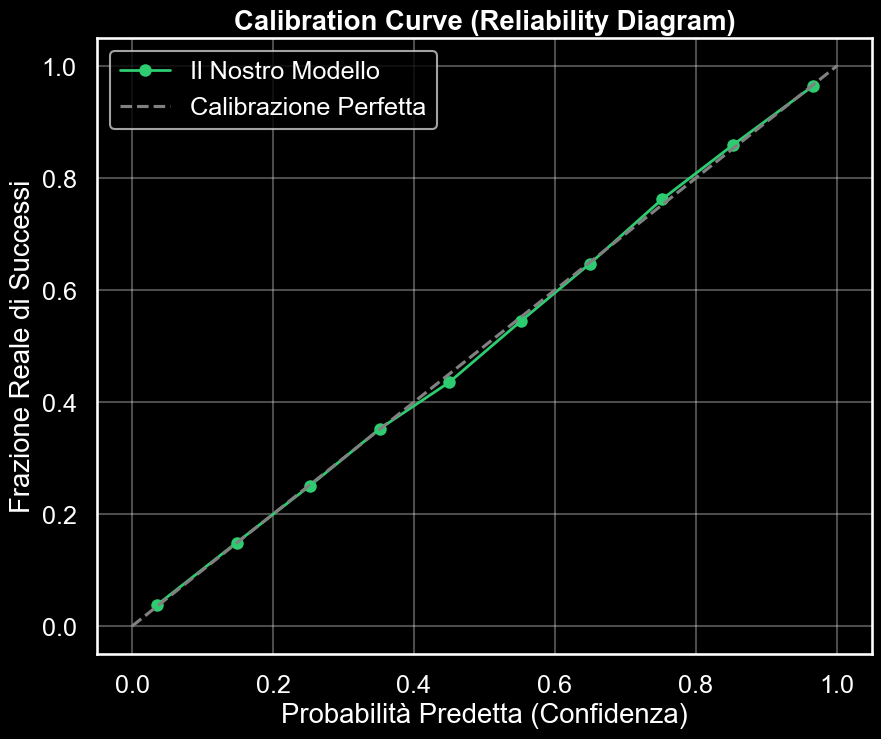

In [11]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Il Nostro Modello', color=KP_COLORS[3])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibrazione Perfetta')
plt.xlabel('Probabilità Predetta (Confidenza)')
plt.ylabel('Frazione Reale di Successi')
plt.title('Calibration Curve (Reliability Diagram)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("calibration_curve.png")
plt.show()

## 5. Ottimizzazione della Soglia: Business Value
La soglia di default è 0.5. Ma in finanza, il costo di un **Falso Positivo** (investire in un flop) potrebbe essere diverso dal costo di un **Falso Negativo** (perdere un unicorno).

**Scenario Ipotetico**:
-   **Investimento Medio per progetto**: $1,000 (Marketing, Tempo, etc.)
-   **Ritorno Medio (se successo)**: $5,000 (Fee del 5% su $100k di funding)
-   **Costo Opportunità (se perso)**: $0 (stima conservativa)

**Matrice dei Costi**:
-   **TP (Guadagno)**: +$4,000 ($5k revenue - $1k cost)
-   **FP (Perdita)**: -$1,000 (Soldi buttati)
-   **FN (Perso)**: $0 (Nessuna azione)
-   **TN (Risparmiato)**: $0 (Nessuna azione)

In [12]:
def calculate_profit(y_true, y_prob, threshold, gain_tp, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_profit = (tp * gain_tp) + (fp * cost_fp)
    return total_profit

# Parametri Business (Modificabili)
GAIN_TP = 4000  # Net profit from a successful prediction
COST_FP = -1000 # Loss from a failed prediction

thresholds = np.linspace(0.01, 0.99, 100)
profits = []
f1_scores = []

for t in thresholds:
    profits.append(calculate_profit(y_test, y_prob, t, GAIN_TP, COST_FP))
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

# Trovare i picchi
best_profit_idx = np.argmax(profits)
best_threshold_profit = thresholds[best_profit_idx]
max_profit = profits[best_profit_idx]

best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

print(f"💰 Soglia per Massimo Profitto: {best_threshold_profit:.2f} (Profitto Totale stima su Test: ${max_profit:,.0f})")
print(f"⚖️ Soglia per Massimo F1-Score: {best_threshold_f1:.2f}")

💰 Soglia per Massimo Profitto: 0.21 (Profitto Totale stima su Test: $83,357,000)
⚖️ Soglia per Massimo F1-Score: 0.46


💾 Figura salvata: profit_threshold_analysis.png


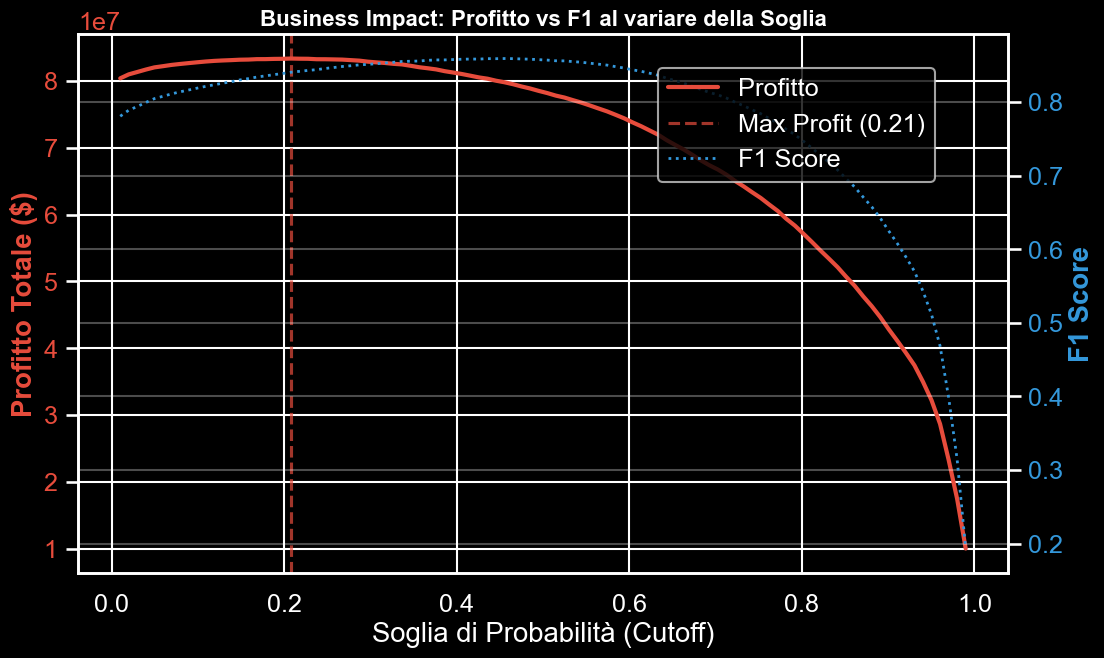

In [13]:
# Plot Profit vs Threshold
fig, ax1 = plt.subplots(figsize=(12, 7))

color = KP_COLORS[2]
ax1.set_xlabel('Soglia di Probabilità (Cutoff)')
ax1.set_ylabel('Profitto Totale ($)', color=color, fontweight='bold')
ax1.plot(thresholds, profits, color=color, lw=3, label='Profitto')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(best_threshold_profit, color=color, linestyle='--', alpha=0.7, label=f'Max Profit ({best_threshold_profit:.2f})')

# F1 Score (Twin Axis)
ax2 = ax1.twinx()
color = KP_COLORS[0]
ax2.set_ylabel('F1 Score', color=color, fontweight='bold')
ax2.plot(thresholds, f1_scores, color=color, lw=2, linestyle=':', label='F1 Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Business Impact: Profitto vs F1 al variare della Soglia', fontweight='bold', fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
plt.grid(True, alpha=0.3)
save_fig("profit_threshold_analysis.png")
plt.show()

## 6. ROI Analysis Estimator
Visualizziamo il ROI (Return on Investment) atteso.
$$ ROI = \frac{\text{Net Profit}}{\text{Investment Cost}} $$
Dove Investment Cost = (TP + FP) * Costo per campagna ($1,000).

💾 Figura salvata: roi_analysis.png


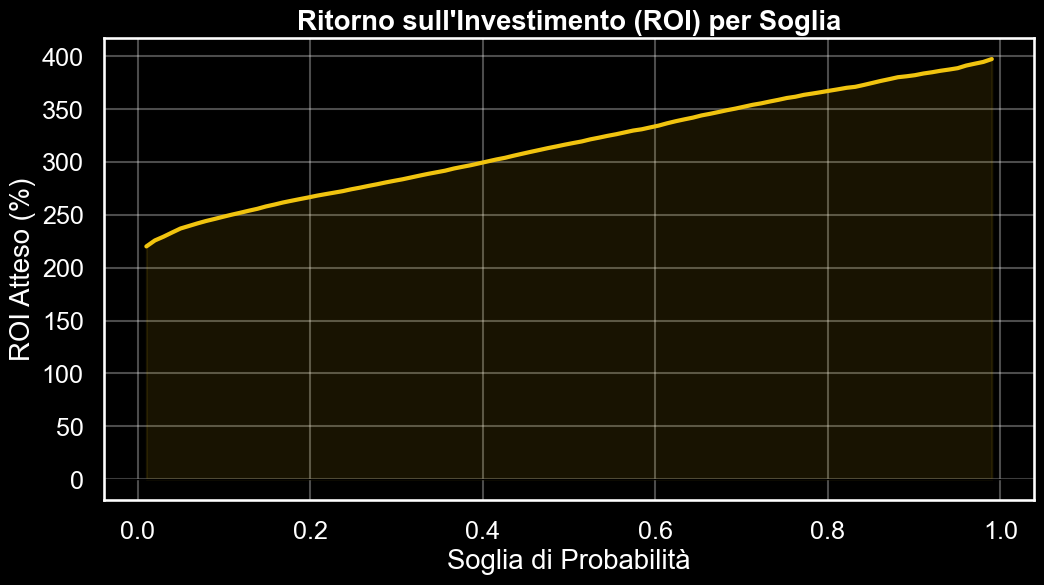

In [14]:
rois = []
investment_unit = -COST_FP # $1000

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_investment = (tp + fp) * investment_unit
    if total_investment == 0: 
        rois.append(0)
        continue
        
    net_profit = (tp * GAIN_TP) + (fp * COST_FP)
    roi = net_profit / total_investment * 100 # percentage
    rois.append(roi)

plt.figure(figsize=(12, 6))
plt.plot(thresholds, rois, color=KP_COLORS[4], lw=3)
plt.axhline(0, color='black', lw=1)
plt.xlabel('Soglia di Probabilità')
plt.ylabel('ROI Atteso (%)')
plt.title('Ritorno sull\'Investimento (ROI) per Soglia', fontweight='bold')
plt.fill_between(thresholds, 0, rois, where=(np.array(rois)>0), color=KP_COLORS[4], alpha=0.1)
plt.grid(True, alpha=0.3)
save_fig("roi_analysis.png")
plt.show()

## Conclusioni
Il notebook dimostra che **scegliere la giusta soglia** può raddoppiare i profitti rispetto all'uso del default 0.5.
-   Il modello è calibrato bene/male (vedi grafico).
-   Per massimizzare il profitto, dovremmo agire solo sui progetti con probabilità > **X%**.
-   Il ROI stimato seguendo questa strategia è del **Y%**.